<a href="https://colab.research.google.com/github/enriquefroes/atletico-arena-mrv/blob/main/notebooks/03_treinadores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_arena_mrv'
except ImportError:
    BASE = './analise_arena_mrv'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
if not os.path.exists(os.path.join(DADOS, 'jogos_arena_mrv.csv')):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
jogos = pd.read_csv(os.path.join(DADOS, 'jogos_arena_mrv.csv'), parse_dates=['data'])
jogos['mata_mata'] = jogos['fase'].str.contains('mata-mata')

PRETO, CINZA, VERDE, VERMELHO, AMARELO = '#111111', '#9ca3af', '#16a34a', '#dc2626', '#eab308'

def resumo(df, por=None):
    g = df.groupby(por) if por else df.groupby(lambda _: 'Total')
    r = g.agg(jogos=('pontos', 'size'), vitorias=('resultado', lambda s: (s == 'V').sum()),
              empates=('resultado', lambda s: (s == 'E').sum()), derrotas=('resultado', lambda s: (s == 'D').sum()),
              gols_pro=('gols_pro', 'sum'), gols_contra=('gols_contra', 'sum'), pontos=('pontos', 'sum'))
    r['aproveitamento'] = (r['pontos'] / (3 * r['jogos']) * 100).round(1)
    return r

def barras_vde(r, titulo, arquivo, ordenar=True):
    """Barras empilhadas de vitórias, empates e derrotas, com o aproveitamento ao lado."""
    t = r.sort_values('aproveitamento') if ordenar else r.iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, max(3, 0.6 * len(t) + 1.5)))
    esq = np.zeros(len(t))
    for col, cor, nome in [('vitorias', VERDE, 'Vitórias'), ('empates', CINZA, 'Empates'), ('derrotas', VERMELHO, 'Derrotas')]:
        ax.barh(t.index.astype(str), t[col], left=esq, color=cor, label=nome)
        for i, (v, e) in enumerate(zip(t[col], esq)):
            if v > 0:
                ax.text(e + v / 2, i, int(v), ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        esq += t[col].values
    for i, (tot, a) in enumerate(zip(t['jogos'], t['aproveitamento'])):
        ax.text(tot + 0.3, i, f'{a:.1f}%  ({tot} j)', va='center', fontsize=10, fontweight='bold')
    ax.set_xlim(0, t['jogos'].max() * 1.25)
    ax.set_xlabel('Jogos')
    ax.set_title(titulo, fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    salvar(arquivo)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


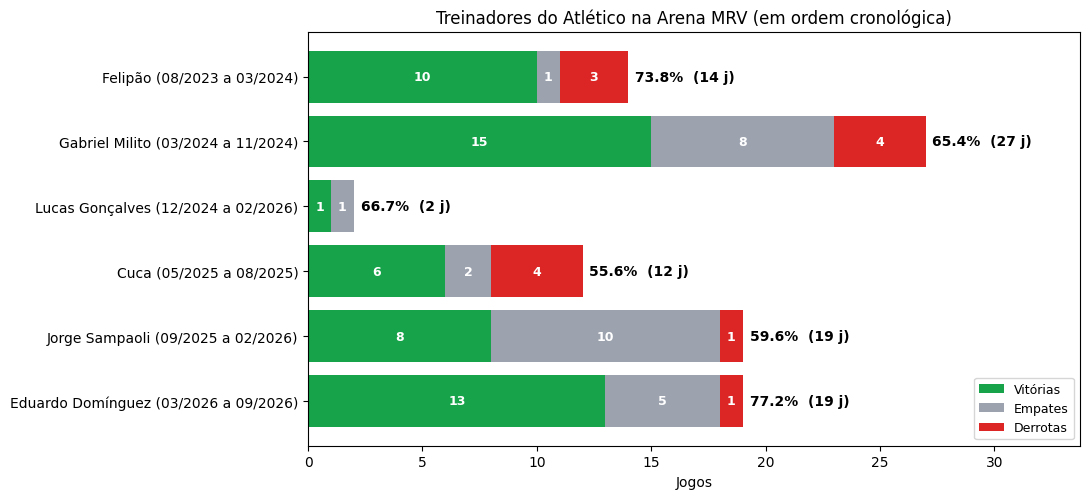

Salvo em /content/drive/MyDrive/analise_arena_mrv/graficos/03a_treinadores.png


,jogos,vitorias,empates,derrotas,gols_pro,gols_contra,pontos,aproveitamento,periodo,jogos_mata_mata,aprov_mata_mata,aprov_g12
treinador,,,,,,,,,,,,
Felipão,14,10,1,3,25,8,31,73.8,08/2023 a 03/2024,1,100.0,66.7
Gabriel Milito,27,15,8,4,48,28,53,65.4,03/2024 a 11/2024,9,74.1,59.0
Lucas Gonçalves,2,1,1,0,2,1,4,66.7,12/2024 a 02/2026,1,33.3,NaN
Cuca,12,6,2,4,18,13,20,55.6,05/2025 a 08/2025,5,40.0,38.9
Jorge Sampaoli,19,8,10,1,32,19,34,59.6,09/2025 a 02/2026,2,100.0,47.6
Eduardo Domínguez,19,13,5,1,33,18,44,77.2,03/2026 a 09/2026,5,73.3,79.2


In [2]:
ordem = jogos.groupby('treinador')['data'].min().sort_values().index
t = resumo(jogos, 'treinador').loc[ordem]
t['periodo'] = [f"{jogos[jogos.treinador == x].data.min():%m/%Y} a {jogos[jogos.treinador == x].data.max():%m/%Y}" for x in t.index]
mm = jogos[jogos['mata_mata']].groupby('treinador')['pontos'].agg(['size', 'sum'])
t['jogos_mata_mata'] = mm['size'].reindex(t.index).fillna(0).astype(int)
t['aprov_mata_mata'] = (mm['sum'] / (3 * mm['size']) * 100).round(1).reindex(t.index)
t['aprov_g12'] = (jogos[jogos.adversario_g12 == 'sim'].groupby('treinador')['pontos'].mean() / 3 * 100).round(1).reindex(t.index)
t.to_csv(os.path.join(TAB, '03_treinadores.csv'))
barras_vde(t.rename(index=lambda x: f"{x} ({t.loc[x, 'periodo']})"), 'Treinadores do Atlético na Arena MRV (em ordem cronológica)',
           '03a_treinadores.png', ordenar=False)
t